In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 


In [2]:
df = pd.read_csv("/Users/anuragpanchal/Documents/MachineLearning/TimeSeries/Superstore_Data.csv")

In [3]:
df

,Order Date,Sales,Profit
0,17-10-2013,5175.1710,919.9710
1,07-11-2011,1822.0800,564.8400
2,14-04-2012,5244.8400,996.4800
3,06-06-2013,3701.5200,1036.0800
4,25-02-2012,1878.7200,582.3600
...,...,...,...
5694,14-01-2013,38.9709,-32.3991
5695,12-11-2014,6.9000,-0.8400
5696,03-11-2011,17.2800,-13.9200
5697,26-07-2013,30.6180,1.0080


In [4]:
df.head()

,Order Date,Sales,Profit
0,17-10-2013,5175.171,919.971
1,07-11-2011,1822.080,564.840
2,14-04-2012,5244.840,996.480
3,06-06-2013,3701.520,1036.080
4,25-02-2012,1878.720,582.360


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5699 entries, 0 to 5698
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order Date  5699 non-null   object 
 1   Sales       5699 non-null   float64
 2   Profit      5699 non-null   float64
dtypes: float64(2), object(1)
memory usage: 133.7+ KB


In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

/var/folders/9v/84kl26095w34d41mph1hlzdc0000gn/T/ipykernel_19517/3072535395.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Order Date'] = pd.to_datetime(df['Order Date'])


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5699 entries, 0 to 5698
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  5699 non-null   datetime64[ns]
 1   Sales       5699 non-null   float64       
 2   Profit      5699 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 133.7 KB


In [8]:
df.sort_values(by = 'Order Date',inplace=True)

In [9]:
df.head()

,Order Date,Sales,Profit
5073,2011-01-01,55.242,15.342
3056,2011-01-01,120.366,36.036
4083,2011-01-01,113.670,37.770
424,2011-01-03,912.456,-319.464
5517,2011-01-03,6.006,0.546


In [10]:
df.reset_index(drop=True,inplace=True)

In [11]:
df.isna().sum()

Order Date    0
Sales         0
Profit        0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(3)

In [13]:
df.set_index('Order Date',inplace=True)

In [14]:
df.head()

,Sales,Profit
Order Date,,
2011-01-01,55.242,15.342
2011-01-01,120.366,36.036
2011-01-01,113.670,37.770
2011-01-03,912.456,-319.464
2011-01-03,6.006,0.546


In [15]:
df['2011-01-01':'2011-02-02']

,Sales,Profit
Order Date,,
2011-01-01,55.242,15.342
2011-01-01,120.366,36.036
2011-01-01,113.670,37.770
2011-01-03,912.456,-319.464
2011-01-03,6.006,0.546
...,...,...
2011-02-01,22.650,9.600
2011-02-01,285.780,71.400
2011-02-01,40.680,11.790


In [16]:
df= df.groupby(pd.Grouper(freq='M')).sum()

/var/folders/9v/84kl26095w34d41mph1hlzdc0000gn/T/ipykernel_19517/3678894806.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df= df.groupby(pd.Grouper(freq='M')).sum()


In [17]:
df.head()

,Sales,Profit
Order Date,,
2011-01-31,15711.7125,991.2825
2011-02-28,12910.8588,1338.8688
2011-03-31,19472.5632,3747.1632
2011-04-30,15440.3046,3846.4746
2011-05-31,24348.9723,3639.9423


In [18]:
df.drop(columns='Profit',inplace=True)

<Axes: xlabel='Order Date'>

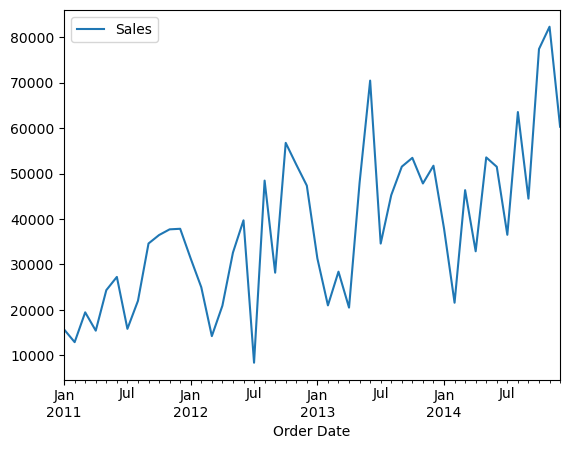

In [19]:
df.plot()

In [20]:
from statsmodels.tsa.stattools import adfuller

In [21]:
adfuller(df['Sales'])[1]

np.float64(0.19876283969416908)

In [22]:
x_train = df[:42]
x_test = df[43:]

In [23]:
x_train.shape,x_test.shape

((42, 1), (5, 1))

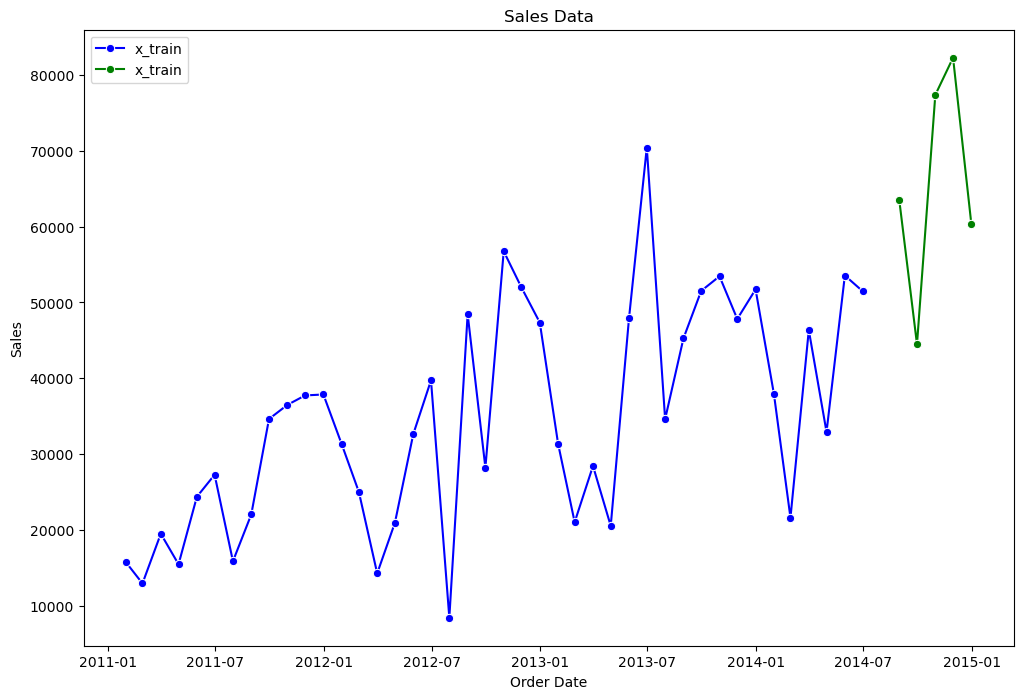

In [24]:
plt.figure(figsize=(12,8))
sns.lineplot(data=x_train,x='Order Date',y='Sales',marker='o' ,color= 'blue',label='x_train')
sns.lineplot(data=x_test,x='Order Date',y='Sales',marker='o' ,color= 'Green',label='x_train')
plt.title("Sales Data")
plt.show()

In [25]:
from scipy.stats import boxcox

In [26]:
df_boxcox = pd.Series(boxcox(x_train['Sales'],lmbda=0),index=x_train.index)

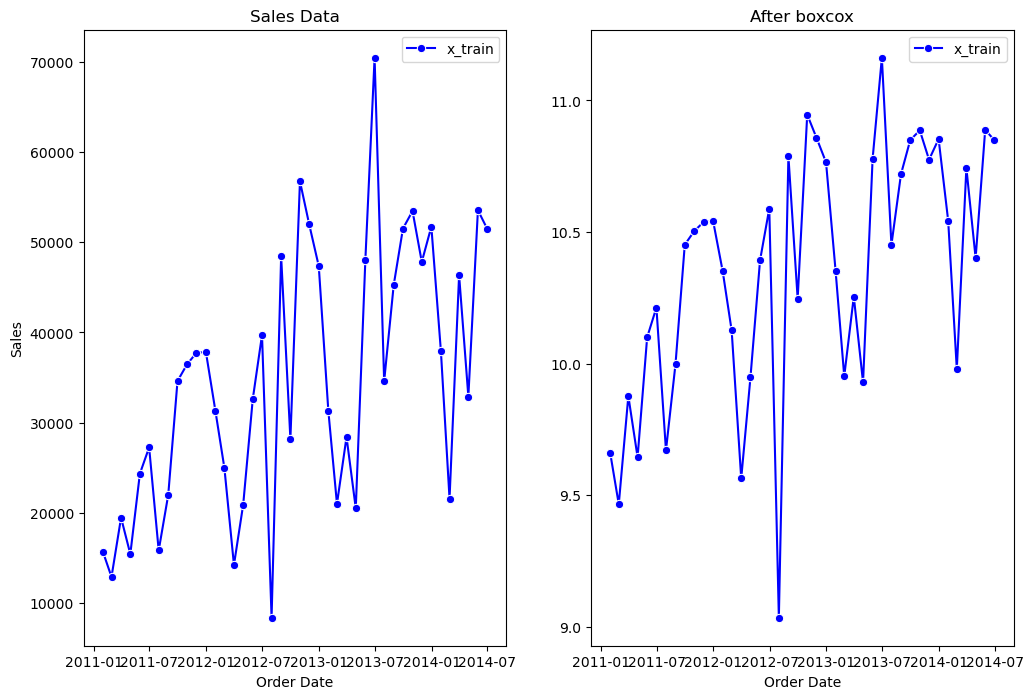

In [27]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
sns.lineplot(data=x_train,x='Order Date',y='Sales',marker='o' ,color= 'blue',label='x_train')
plt.title("Sales Data")
plt.subplot(1,2,2)
sns.lineplot(x=df_boxcox.index,y=df_boxcox.values,marker='o' ,color= 'blue',label='x_train')
plt.title("After boxcox")
plt.show()

In [28]:
x_train_difference =  x_train['Sales'].diff()

In [29]:
x_train_difference


Order Date
2011-01-31           NaN
2011-02-28    -2800.8537
2011-03-31     6561.7044
2011-04-30    -4032.2586
2011-05-31     8908.6677
2011-06-30     2911.0473
2011-07-31   -11417.1879
2011-08-31     6169.4049
2011-09-30    12600.9483
2011-10-31     1858.8621
2011-11-30     1250.5569
2011-12-31      124.3872
2012-01-31    -6566.1276
2012-02-29    -6295.1754
2012-03-31   -10744.5120
2012-04-30     6685.2960
2012-05-31    11682.1491
2012-06-30     7101.4140
2012-07-31   -31320.3036
2012-08-31    40055.0661
2012-09-30   -20251.5741
2012-10-31    28549.8597
2012-11-30    -4776.0693
2012-12-31    -4623.3873
2013-01-31   -16015.3647
2013-02-28   -10328.5242
2013-03-31     7414.8831
2013-04-30    -7905.9012
2013-05-31    27470.8803
2013-06-30    22457.2089
2013-07-31   -35839.9842
2013-08-31    10654.8192
2013-09-30     6261.5796
2013-10-31     1935.3297
2013-11-30    -5635.7748
2013-12-31     3904.8420
2014-01-31   -13793.2908
2014-02-28   -16339.8210
2014-03-31    24755.6010
2014-04-30   -

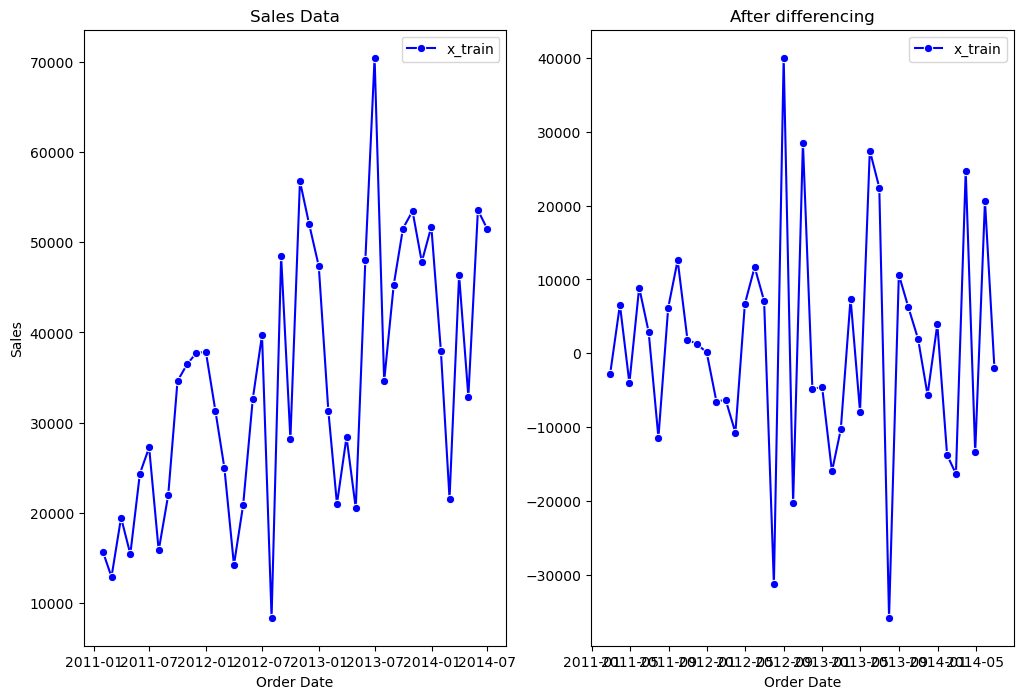

In [30]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
sns.lineplot(data=x_train,x='Order Date',y='Sales',marker='o' ,color= 'blue',label='x_train')
plt.title("Sales Data")
plt.subplot(1,2,2)
sns.lineplot(x=x_train_difference.index,y=x_train_difference.values,marker='o' ,color= 'blue',label='x_train')
plt.title("After differencing")
plt.show()

In [31]:
df_boxcox_dif = df_boxcox.diff()

In [32]:
from statsmodels.graphics.tsaplots import  plot_acf

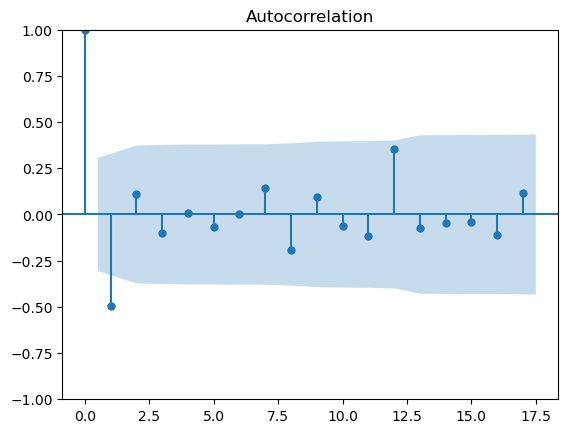

In [33]:
plot_acf(df_boxcox_dif[1:]);
#q values is 1

In [ ]:
s

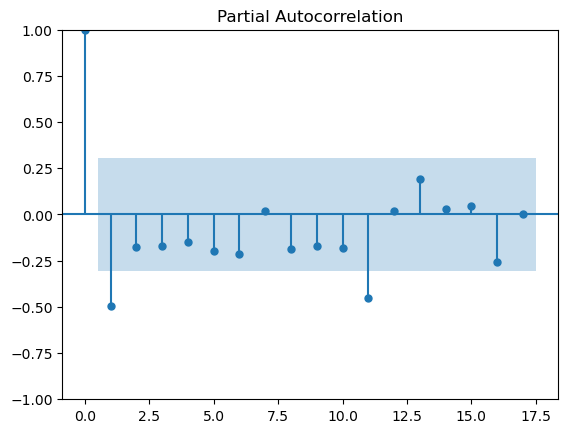

In [35]:
plot_pacf(df_boxcox_dif[1:]);
#p value is 1

In [36]:
from statsmodels.tsa.arima.model import ARIMA

In [37]:
ar_model = ARIMA(df_boxcox_dif,order=(1,0,0))

In [42]:
ar_model = ar_model.fit()

In [43]:
train_len = 42
ar_model_pred = ar_model.predict(start=42,end=47)

In [45]:
ar_model_pred

2014-07-31    0.065469
2014-08-31    0.014786
2014-09-30    0.039315
2014-10-31    0.027443
2014-11-30    0.033189
2014-12-31    0.030408
Freq: ME, Name: predicted_mean, dtype: float64

In [46]:
ar_model_pred = pd.concat([df_boxcox_dif,ar_model_pred])

In [49]:
ar_model_pred = ar_model_pred.cumsum()
ar_model_pred  = ar_model_pred.add(df_boxcox[0])
df_pred = np.exp(ar_model_pred)

/var/folders/9v/84kl26095w34d41mph1hlzdc0000gn/T/ipykernel_19517/3903134461.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ar_model_pred  = ar_model_pred.add(df_boxcox[0])


In [50]:
df_pred

2011-01-31             NaN
2011-02-28    12910.858800
2011-03-31    19472.563200
2011-04-30    15440.304600
2011-05-31    24348.972300
2011-06-30    27260.019600
2011-07-31    15842.831700
2011-08-31    22012.236600
2011-09-30    34613.184900
2011-10-31    36472.047000
2011-11-30    37722.603900
2011-12-31    37846.991100
2012-01-31    31280.863500
2012-02-29    24985.688100
2012-03-31    14241.176100
2012-04-30    20926.472100
2012-05-31    32608.621200
2012-06-30    39710.035200
2012-07-31     8389.731600
2012-08-31    48444.797700
2012-09-30    28193.223600
2012-10-31    56743.083300
2012-11-30    51967.014000
2012-12-31    47343.626700
2013-01-31    31328.262000
2013-02-28    20999.737800
2013-03-31    28414.620900
2013-04-30    20508.719700
2013-05-31    47979.600000
2013-06-30    70436.808900
2013-07-31    34596.824700
2013-08-31    45251.643900
2013-09-30    51513.223500
2013-10-31    53448.553200
2013-11-30    47812.778400
2013-12-31    51717.620400
2014-01-31    37924.329600
2

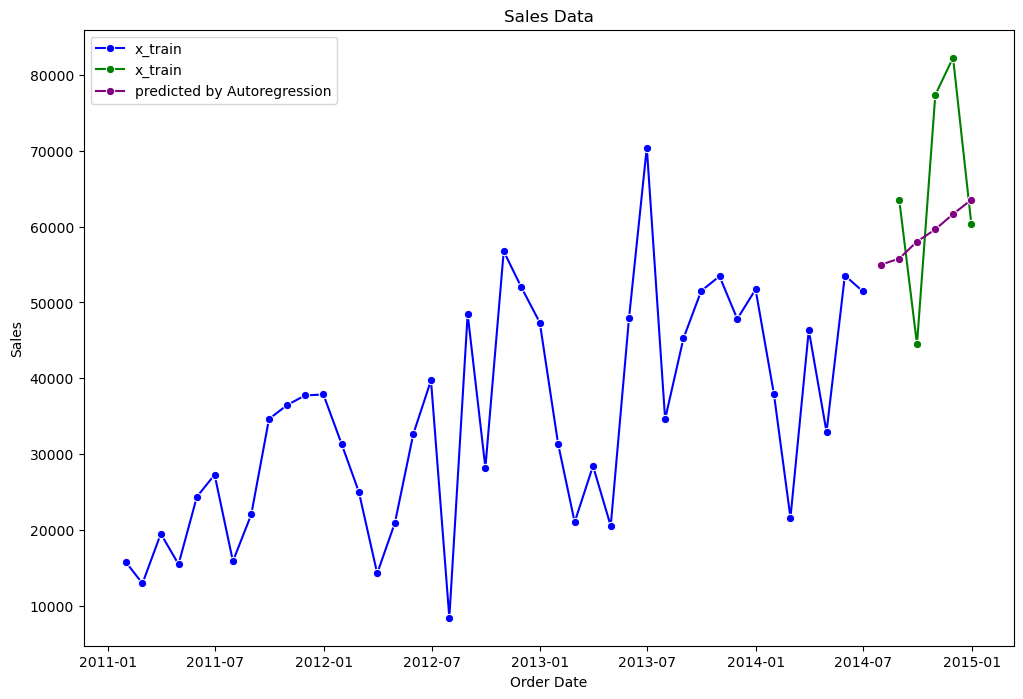

In [53]:
plt.figure(figsize=(12,8))
sns.lineplot(data=x_train,x='Order Date',y='Sales',marker='o' ,color= 'blue',label='x_train')
sns.lineplot(data=x_test,x='Order Date',y='Sales',marker='o' ,color= 'Green',label='x_train')
sns.lineplot(x=df_pred.index[42:],y=df_pred.values[42:],marker='o' ,color= 'Purple',label='predicted by Autoregression')
plt.title("Sales Data")
plt.show()

In [54]:
from sklearn.metrics import *

In [59]:
rmse = np.sqrt(mean_squared_error(y_true=x_test['Sales'].values,y_pred=df_pred.values[42:47]))

In [60]:
rmse

np.float64(14768.847216301494)

In [61]:
arima_model = ARIMA(df_boxcox,order=(1,0,1))

In [62]:
arima_model = arima_model.fit()

In [63]:
arima_model

In [64]:
arima_pred = arima_model.predict(start=42 ,end=47)

In [65]:
arima_pred

2014-07-31    10.597482
2014-08-31    10.554442
2014-09-30    10.518248
2014-10-31    10.487811
2014-11-30    10.462216
2014-12-31    10.440692
Freq: ME, Name: predicted_mean, dtype: float64

In [66]:
arima_pred = pd.concat([df_boxcox,arima_pred])

In [67]:
arima_pred

2011-01-31     9.662162
2011-02-28     9.465824
2011-03-31     9.876762
2011-04-30     9.644737
2011-05-31    10.100245
2011-06-30    10.213176
2011-07-31     9.670472
2011-08-31     9.999354
2011-09-30    10.451990
2011-10-31    10.504301
2011-11-30    10.538015
2011-12-31    10.541307
2012-01-31    10.350762
2012-02-29    10.126058
2012-03-31     9.563893
2012-04-30     9.948770
2012-05-31    10.392332
2012-06-30    10.589359
2012-07-31     9.034764
2012-08-31    10.788180
2012-09-30    10.246837
2012-10-31    10.946289
2012-11-30    10.858364
2012-12-31    10.765187
2013-01-31    10.352276
2013-02-28     9.952265
2013-03-31    10.254659
2013-04-30     9.928605
2013-05-31    10.778531
2013-06-30    11.162471
2013-07-31    10.451517
2013-08-31    10.719994
2013-09-30    10.849594
2013-10-31    10.886475
2013-11-30    10.775048
2013-12-31    10.853554
2014-01-31    10.543348
2014-02-28     9.979731
2014-03-31    10.743763
2014-04-30    10.401152
2014-05-31    10.888275
2014-06-30    10

In [68]:
arima_pred = np.exp(arima_pred)

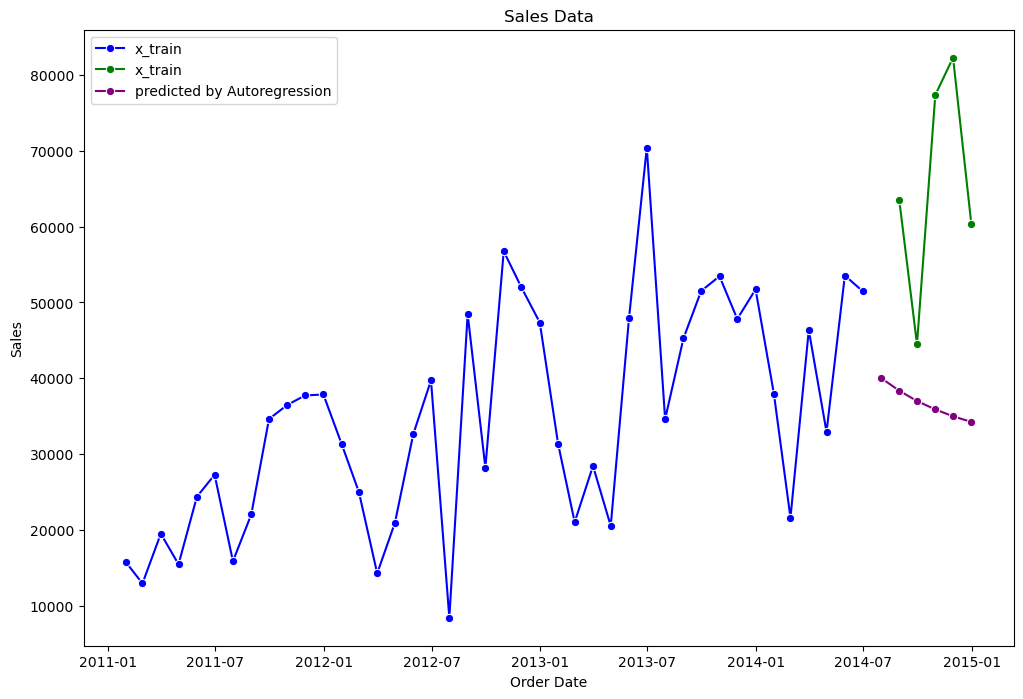

In [69]:
plt.figure(figsize=(12,8))
sns.lineplot(data=x_train,x='Order Date',y='Sales',marker='o' ,color= 'blue',label='x_train')
sns.lineplot(data=x_test,x='Order Date',y='Sales',marker='o' ,color= 'Green',label='x_train')
sns.lineplot(x=arima_pred.index[42:],y=arima_pred.values[42:],marker='o' ,color= 'Purple',label='predicted by Autoregression')
plt.title("Sales Data")
plt.show()

In [71]:
rmse = np.sqrt(mean_squared_error(y_true=x_test['Sales'].values,y_pred=arima_pred.values[42:47]))
rmse

np.float64(31674.233207777437)

In [72]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [73]:
sarima_model =SARIMAX(df_boxcox,order=(1,0,1),seasonal_order=(1,0,1,12))
sarima_model = sarima_model.fit()

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [74]:
sarima_pred = sarima_model.predict(start=42,end=47)

In [75]:
sarima_pred = pd.concat([df_boxcox,sarima_pred])

In [76]:
sarima_pred = np.exp(sarima_pred)

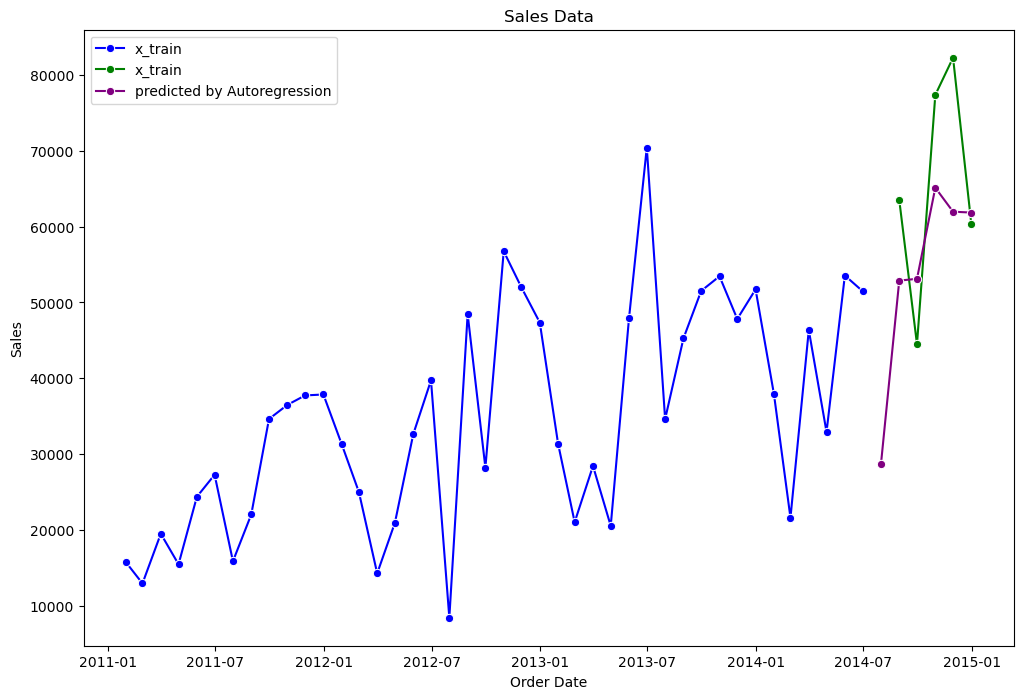

In [77]:
plt.figure(figsize=(12,8))
sns.lineplot(data=x_train,x='Order Date',y='Sales',marker='o' ,color= 'blue',label='x_train')
sns.lineplot(data=x_test,x='Order Date',y='Sales',marker='o' ,color= 'Green',label='x_train')
sns.lineplot(x=sarima_pred.index[42:],y=sarima_pred.values[42:],marker='o' ,color= 'Purple',label='predicted by Autoregression')
plt.title("Sales Data")
plt.show()

In [78]:
rmse = np.sqrt(mean_squared_error(y_true=x_test['Sales'].values,y_pred=sarima_pred.values[42:47]))
rmse

np.float64(20858.046900994923)